# Optimal Strategy — Entry Timing, Training Data, and Portfolio Simulation

**Goal:** Answer three questions definitively:
1. **When to enter?** — What elapsed % window gives the best results with bid <= 0.85?
2. **What data to train on?** — Full dataset or only the trading window?
3. **How profitable is it?** — Starting with $1,000, what would the balance be?

**Setup:** LogisticRegression (best model from notebook 3), all features, bid <= 0.85 (max realistic entry cost).

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from evaluator import Evaluator
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

MAX_BID = 0.85

## 1. Load data

**What:** Same preprocessing as notebooks 3 and 4. We also compute `winner_bid` (max of UP and DOWN best bid) to filter out snapshots where the market has already decided.

In [2]:
DATA_PATH = Path("../data/legacy_features.jsonl")

rows = []
with open(DATA_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)
df["winner_bid"] = df[["up_best_bid", "down_best_bid"]].max(axis=1)

NON_FEATURE_COLS = {
    "candle_id",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
    "winner_bid",
}
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
df[feature_cols] = df[feature_cols].fillna(0.0)

print(f"Loaded {len(df):,} rows, {len(feature_cols)} features")

Loaded 94,336 rows, 54 features


## 2. Question 1 — Training data: full dataset vs filtered?

**What:** For each elapsed threshold, compare two strategies:
- **Strategy A:** Train on ALL data, evaluate only on the filtered window
- **Strategy B:** Train ONLY on the filtered window, evaluate on the filtered window

**Why this matters:** Strategy A has more training data but the model learns from snapshots outside the trading window (including late-candle easy predictions). Strategy B has less data but every training example matches what the model will see in production.

**How to read the results:**
- Higher ROI = better. ROI measures actual profit after entry costs.
- If Strategy B wins → the model benefits from focused training data
- If Strategy A wins → more data helps even if it's outside the window

In [3]:
def simulate_pnl(pred, y_te, asks_te):
    """Calculate PnL, win rate, and bet count for UP-only betting."""
    pnl, nb, wins = 0.0, 0, 0
    for p, t, a in zip(pred, y_te, asks_te, strict=True):
        if p == 1 and np.isfinite(a) and 0 < a < MAX_BID:
            nb += 1
            if t == 1:
                pnl += 1.0 - a
                wins += 1
            else:
                pnl -= a
    wr = wins / nb if nb > 0 else 0
    valid_asks = [a for p, a in zip(pred, asks_te, strict=True) if p == 1 and np.isfinite(a) and 0 < a < MAX_BID]
    avg_a = np.mean(valid_asks) if valid_asks else 0
    roi = pnl / (nb * avg_a) * 100 if nb > 0 and avg_a > 0 else 0
    return {"pnl": pnl, "n_bets": nb, "wins": wins, "win_rate": wr, "avg_entry": avg_a, "roi": roi}

In [4]:
elapsed_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_a = []  # Strategy A: train on all
results_b = []  # Strategy B: train on filtered

# --- Strategy A: train on ALL data ---
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(df[feature_cols].values)
y_full = df["target"].values
asks_full = df["up_best_ask"].values
elapsed_full = df["elapsed_pct"].values
wbid_full = df["winner_bid"].values

X_tr_f, X_te_f, y_tr_f, y_te_f, meta_tr, meta_te = train_test_split(
    X_full,
    y_full,
    np.column_stack([asks_full, elapsed_full, wbid_full]),
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)
model_a = LogisticRegression(max_iter=1000, random_state=42)
model_a.fit(X_tr_f, y_tr_f)
pred_a_all = model_a.predict(X_te_f)

print(f"{'Elapsed':<12} {'Strategy A (train=all)':>40} {'Strategy B (train=filtered)':>40}")
print(f"{'':12} {'acc':>8} {'bets':>6} {'wr':>7} {'ROI':>8} {'acc':>8} {'bets':>6} {'wr':>7} {'ROI':>8}")
print("-" * 95)

for min_e in elapsed_thresholds:
    # Strategy A: filter test set only
    tmask = (meta_te[:, 1] >= min_e) & (meta_te[:, 2] <= MAX_BID)
    if tmask.sum() < 100:
        continue
    pred_a = pred_a_all[tmask]
    y_a = y_te_f[tmask]
    asks_a = meta_te[tmask, 0]
    acc_a = np.mean(pred_a == y_a)
    pnl_a = simulate_pnl(pred_a, y_a, asks_a)
    results_a.append({"min_e": min_e, "acc": acc_a, **pnl_a})

    # Strategy B: filter both train and test
    mask_b = (df["elapsed_pct"] >= min_e) & (df["winner_bid"] <= MAX_BID)
    df_b = df[mask_b]
    X_b = StandardScaler().fit_transform(df_b[feature_cols].values)
    y_b = df_b["target"].values
    asks_b = df_b["up_best_ask"].values
    X_tr_b, X_te_b, y_tr_b, y_te_b, asks_tr_b, asks_te_b = train_test_split(
        X_b, y_b, asks_b, test_size=0.2, random_state=42, stratify=y_b
    )
    model_b = LogisticRegression(max_iter=1000, random_state=42)
    model_b.fit(X_tr_b, y_tr_b)
    pred_b = model_b.predict(X_te_b)
    acc_b = np.mean(pred_b == y_te_b)
    pnl_b = simulate_pnl(pred_b, y_te_b, asks_te_b)
    results_b.append({"min_e": min_e, "acc": acc_b, **pnl_b})

    print(
        f"  e>={min_e:.0%}      "
        f"{acc_a * 100:>7.1f}% {pnl_a['n_bets']:>5} {pnl_a['win_rate'] * 100:>6.1f}% {pnl_a['roi']:>+7.1f}%"
        f"{acc_b * 100:>8.1f}% {pnl_b['n_bets']:>5} {pnl_b['win_rate'] * 100:>6.1f}% {pnl_b['roi']:>+7.1f}%"
    )

Elapsed                        Strategy A (train=all)              Strategy B (train=filtered)
                  acc   bets      wr      ROI      acc   bets      wr      ROI
-----------------------------------------------------------------------------------------------
  e>=0%         66.1%  5959   65.1%    +0.4%    66.7%  5783   65.8%    +1.7%
  e>=10%         67.0%  5329   65.9%    +0.5%    67.5%  5140   66.5%    +1.4%
  e>=20%         68.1%  4452   66.8%    +1.2%    69.3%  4309   67.7%    +3.2%
  e>=30%         68.6%  3571   67.2%    +1.2%    70.2%  3473   69.3%    +5.7%
  e>=40%         69.2%  2789   67.9%    +1.6%    70.4%  2670   70.0%    +6.5%
  e>=50%         69.9%  2091   68.7%    +2.3%    70.7%  2084   69.6%    +5.8%
  e>=60%         69.9%  1475   69.2%    +3.2%    69.7%  1439   69.1%    +5.6%
  e>=70%         71.1%   993   69.5%    +3.2%    71.9%   951   69.7%    +5.4%


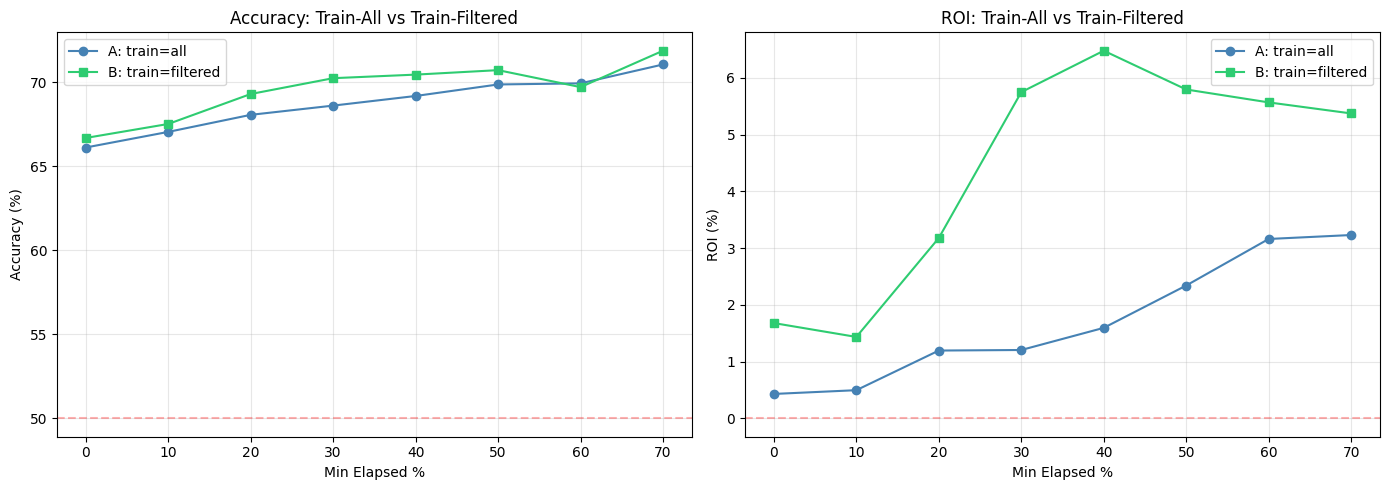

Best Strategy A: e>=70% → ROI=+3.2%
Best Strategy B: e>=40% → ROI=+6.5%

Winner: Strategy B (train on filtered)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = [r["min_e"] * 100 for r in results_a]
axes[0].plot(x, [r["acc"] * 100 for r in results_a], "o-", label="A: train=all", color="steelblue")
axes[0].plot(x, [r["acc"] * 100 for r in results_b], "s-", label="B: train=filtered", color="#2ecc71")
axes[0].set_xlabel("Min Elapsed %")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy: Train-All vs Train-Filtered")
axes[0].legend()
axes[0].axhline(50, color="red", linestyle="--", alpha=0.3)
axes[0].grid(alpha=0.3)

axes[1].plot(x, [r["roi"] for r in results_a], "o-", label="A: train=all", color="steelblue")
axes[1].plot(x, [r["roi"] for r in results_b], "s-", label="B: train=filtered", color="#2ecc71")
axes[1].set_xlabel("Min Elapsed %")
axes[1].set_ylabel("ROI (%)")
axes[1].set_title("ROI: Train-All vs Train-Filtered")
axes[1].legend()
axes[1].axhline(0, color="red", linestyle="--", alpha=0.3)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Winner
best_b = max(results_b, key=lambda r: r["roi"])
best_a = max(results_a, key=lambda r: r["roi"])
print(f"Best Strategy A: e>={best_a['min_e']:.0%} → ROI={best_a['roi']:+.1f}%")
print(f"Best Strategy B: e>={best_b['min_e']:.0%} → ROI={best_b['roi']:+.1f}%")
print(f"\nWinner: {'Strategy B (train on filtered)' if best_b['roi'] > best_a['roi'] else 'Strategy A (train on all)'}")

## 3. Question 2 — The optimal entry window

**What:** Using the winning training strategy from above, find the single best elapsed threshold.

**How to read:** We want the threshold that maximizes ROI while maintaining enough bets to be statistically meaningful. High accuracy at elapsed >= 70% is nice, but you only get ~1,000 bets. Lower thresholds give more opportunities.

In [6]:
# Pick winning strategy
winner = results_b if best_b["roi"] > best_a["roi"] else results_a
strategy_label = "B (train=filtered)" if best_b["roi"] > best_a["roi"] else "A (train=all)"

print(f"Using {strategy_label}")
print(f"\n{'Elapsed':<10} {'Acc':>7} {'Bets':>6} {'WinRate':>8} {'AvgEntry':>9} {'PnL':>10} {'ROI':>8}")
print("-" * 65)
for r in winner:
    marker = " ◀ BEST" if r["roi"] == max(w["roi"] for w in winner) else ""
    print(
        f"  e>={r['min_e']:.0%}   {r['acc'] * 100:>6.1f}% {r['n_bets']:>5} {r['win_rate'] * 100:>7.1f}% "
        f"${r['avg_entry']:.3f}  ${r['pnl']:>+9.2f} {r['roi']:>+7.1f}%{marker}"
    )

optimal = max(winner, key=lambda r: r["roi"])
OPTIMAL_ELAPSED = optimal["min_e"]
print(
    f"\nOPTIMAL ENTRY: elapsed >= {OPTIMAL_ELAPSED:.0%} ({OPTIMAL_ELAPSED * 5:.0f} min into candle), bid <= {MAX_BID}"
)
print(
    f"Expected: {optimal['win_rate'] * 100:.1f}% win rate, ${optimal['avg_entry']:.3f} avg entry, {optimal['roi']:+.1f}% ROI"
)

Using B (train=filtered)

Elapsed        Acc   Bets  WinRate  AvgEntry        PnL      ROI
-----------------------------------------------------------------
  e>=0%     66.7%  5783    65.8% $0.647  $   +62.83    +1.7%
  e>=10%     67.5%  5140    66.5% $0.655  $   +48.30    +1.4%
  e>=20%     69.3%  4309    67.7% $0.656  $   +89.88    +3.2%
  e>=30%     70.2%  3473    69.3% $0.656  $  +130.88    +5.7%
  e>=40%     70.4%  2670    70.0% $0.658  $  +113.76    +6.5% ◀ BEST
  e>=50%     70.7%  2084    69.6% $0.658  $   +79.47    +5.8%
  e>=60%     69.7%  1439    69.1% $0.655  $   +52.47    +5.6%
  e>=70%     71.9%   951    69.7% $0.662  $   +33.80    +5.4%

OPTIMAL ENTRY: elapsed >= 40% (2 min into candle), bid <= 0.85
Expected: 70.0% win rate, $0.658 avg entry, +6.5% ROI


## 4. Final model — train and evaluate

**What:** Train the final model on the optimal configuration and show full evaluation.

**How to read the charts:**
- **Predictions scatter:** Green dots = correct, red = incorrect. Good model has separation above/below 0.5 threshold.
- **Error distribution:** Centered at 0 = unbiased. Narrow = precise.
- **Confusion matrix:** Diagonal = correct predictions. Off-diagonal = errors.

=== Final Model (e>=40%, bid<=0.85) ===
  Regression:      MSE=0.1947  R²=22.1%  MAE=0.3896
  Classification:  Accuracy=70.4%  Precision=70.9%  Recall=70.0%  F1=70.4%
  Samples:         5888 (UP=2964, DOWN=2924)


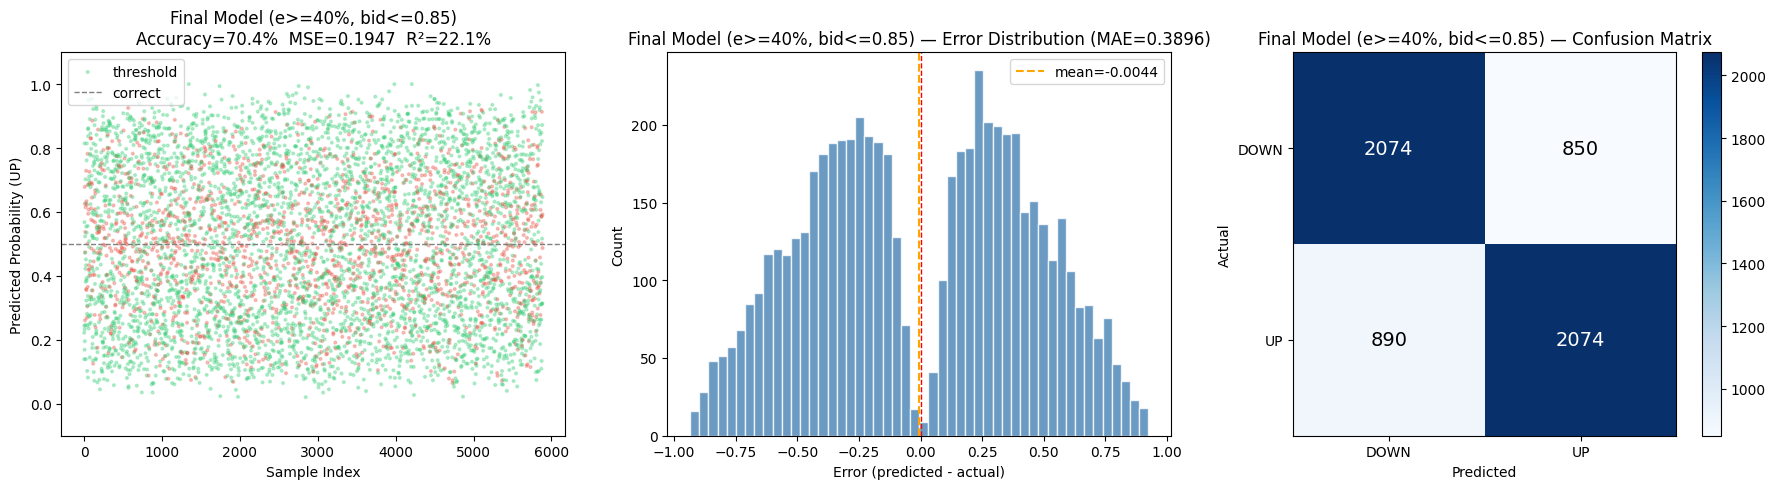

In [7]:
# Train final model on optimal window
mask_final = (df["elapsed_pct"] >= OPTIMAL_ELAPSED) & (df["winner_bid"] <= MAX_BID)
df_final = df[mask_final]

X_final = StandardScaler().fit_transform(df_final[feature_cols].values)
y_final = df_final["target"].values
asks_final = df_final["up_best_ask"].values

X_tr, X_te, y_tr, y_te, asks_tr, asks_te = train_test_split(
    X_final, y_final, asks_final, test_size=0.2, random_state=42, stratify=y_final
)

model_final = LogisticRegression(max_iter=1000, random_state=42)
model_final.fit(X_tr, y_tr)

y_prob = model_final.predict_proba(X_te)[:, 1]
y_pred = model_final.predict(X_te)

ev = Evaluator(y_te, y_pred, y_prob, title=f"Final Model (e>={OPTIMAL_ELAPSED:.0%}, bid<={MAX_BID})")
ev.full_report()

## 5. Portfolio simulation — $1,000 starting balance

**What:** Simulate sequential betting on the test set with different position sizing strategies, starting from $1,000.

**Strategies tested:**
- **Flat $10/bet** — simple, no compounding. Shows raw edge.
- **Flat $20/bet** — double the size, double the risk.
- **1% of balance** — mild compounding. Grows slowly but safely.
- **2% of balance** — moderate compounding. Standard Kelly-fraction approach.
- **2% + confidence filter** — only bet when model probability > 0.6. Fewer bets, higher win rate.

**How to read:**
- Flat bets show linear growth — the dollar gain per bet is constant
- % of balance shows exponential growth — each win increases the next bet size
- The confidence filter trades fewer bets for higher quality

**Caveat:** This is a backtest on shuffled data, NOT a temporal simulation. Real results will differ due to:
- Slippage and fees (not modeled)
- Market impact (large bets move the price)
- Temporal autocorrelation (consecutive candles may be correlated)
- Regime changes (the market may behave differently in the future)

In [8]:
def simulate_portfolio(pred, y_te, asks_te, prob, start_balance, sizing, conf_threshold=0.0):
    """Simulate portfolio growth. Returns (balance, history, n_bets, wins)."""
    balance = start_balance
    history = [balance]
    n_bets, wins = 0, 0

    for p, t, a, pr in zip(pred, y_te, asks_te, prob, strict=True):
        if p != 1 or not np.isfinite(a) or a <= 0 or a >= MAX_BID or pr < conf_threshold:
            continue

        if sizing["type"] == "flat":
            bet_size = min(sizing["amount"], balance)
        else:
            bet_size = balance * sizing["fraction"]

        if bet_size < 1 or balance < bet_size:
            continue

        shares = bet_size / a
        n_bets += 1

        if t == 1:
            balance += shares * (1.0 - a)
            wins += 1
        else:
            balance -= bet_size

        history.append(balance)

    return balance, history, n_bets, wins


START = 1000.0
strategies = [
    ("Flat $10/bet", {"type": "flat", "amount": 10}, 0.0),
    ("Flat $20/bet", {"type": "flat", "amount": 20}, 0.0),
    ("1% of balance", {"type": "pct", "fraction": 0.01}, 0.0),
    ("2% of balance", {"type": "pct", "fraction": 0.02}, 0.0),
    ("2% + conf>0.6", {"type": "pct", "fraction": 0.02}, 0.6),
]

sim_results = []
print(f"{'Strategy':<25} {'Bets':>6} {'WinRate':>8} {'Final $':>12} {'Return':>10}")
print("-" * 65)

for name, sizing, conf in strategies:
    bal, hist, nb, w = simulate_portfolio(y_pred, y_te, asks_te, y_prob, START, sizing, conf)
    wr = w / nb if nb > 0 else 0
    ret = (bal - START) / START * 100
    sim_results.append({"name": name, "balance": bal, "history": hist, "n_bets": nb, "win_rate": wr, "return": ret})
    print(f"{name:<25} {nb:>5} {wr * 100:>7.1f}% ${bal:>11,.2f} {ret:>+9.1f}%")

Strategy                    Bets  WinRate      Final $     Return
-----------------------------------------------------------------
Flat $10/bet               2670    70.0% $   3,915.81    +291.6%
Flat $20/bet               2670    70.0% $   6,831.62    +583.2%
1% of balance              2670    70.0% $  16,839.11   +1583.9%
2% of balance              2670    70.0% $ 236,111.29  +23511.1%
2% + conf>0.6              1914    76.2% $ 130,877.00  +12987.7%


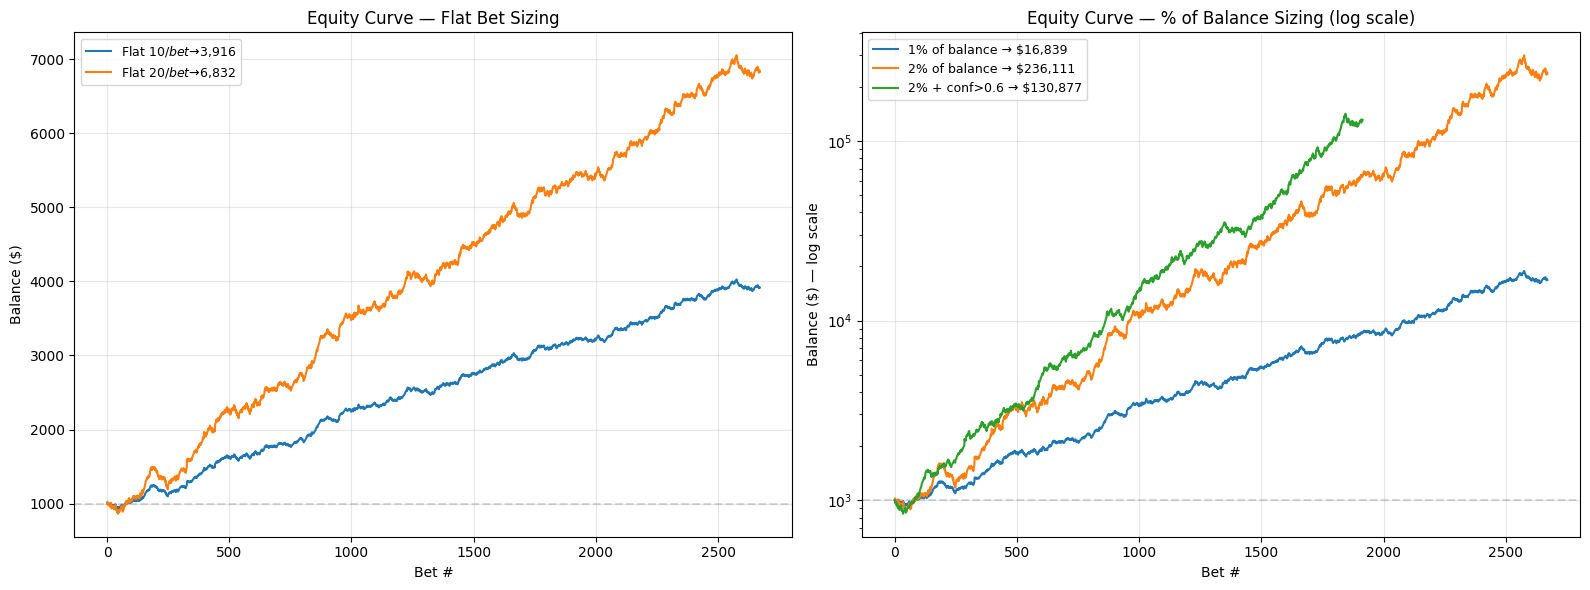

In [9]:
# Equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale (flat bets)
for r in sim_results[:2]:  # flat strategies
    axes[0].plot(r["history"], label=f"{r['name']} → ${r['balance']:,.0f}")
axes[0].axhline(START, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Bet #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("Equity Curve — Flat Bet Sizing")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Log scale (% of balance — exponential growth)
for r in sim_results[2:]:  # pct strategies
    axes[1].plot(r["history"], label=f"{r['name']} → ${r['balance']:,.0f}")
axes[1].axhline(START, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Bet #")
axes[1].set_ylabel("Balance ($) — log scale")
axes[1].set_yscale("log")
axes[1].set_title("Equity Curve — % of Balance Sizing (log scale)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. What do winning bets have in common?

**What:** Analyze the test predictions from the final model. Separate correct UP predictions (wins) from incorrect UP predictions (losses) and compare their feature profiles. Then train a Decision Tree to find explicit rules — "prefilter conditions" — that identify when the model is likely to be right.

**Why:** Even a 70% win rate model is wrong 30% of the time. If we can identify *conditions* under which the model is more reliable (e.g., "when model confidence > 0.7 AND volatility is low"), we can use those as a prefilter: only bet when conditions match. This would trade fewer bets for a higher win rate — exactly the trade-off the bot should make.

**Three analyses:**
1. **Feature comparison:** Which indicators differ most between wins and losses? (Effect size ranking)
2. **Confidence calibration:** How does win rate change with model confidence? (Probability buckets)
3. **Decision tree rules:** Explicit if/then rules for "should we trust this prediction?" (Prefilter)

In [10]:
# Separate correct and incorrect UP predictions
bet_mask = y_pred == 1  # model says UP
correct = (y_pred == y_te) & bet_mask
wrong = (y_pred != y_te) & bet_mask

print(f"Test set: {len(y_te):,} samples")
print(f"Bets placed (pred=UP): {bet_mask.sum():,} ({bet_mask.mean() * 100:.1f}%)")
print(f"  Correct (wins):  {correct.sum():,} ({correct.sum() / bet_mask.sum() * 100:.1f}% of bets)")
print(f"  Wrong (losses):  {wrong.sum():,} ({wrong.sum() / bet_mask.sum() * 100:.1f}% of bets)")
print(f"No bet (pred=DOWN): {(~bet_mask).sum():,}")

Test set: 5,888 samples
Bets placed (pred=UP): 2,924 (49.7%)
  Correct (wins):  2,074 (70.9% of bets)
  Wrong (losses):  850 (29.1% of bets)
No bet (pred=DOWN): 2,964


### 6a. Feature comparison — wins vs losses

**How to read:** For each feature, we compute the mean value for winning bets vs losing bets, then the effect size (|difference| / pooled std). Higher effect size = that feature is more different between wins and losses = better prefilter candidate.

- **Positive diff** = winning bets have *higher* values of this feature
- **Negative diff** = winning bets have *lower* values
- **Effect > 0.2** = strong differentiator
- **Effect > 0.1** = moderate differentiator

Feature                          Win mean  Lose mean       Diff   |Effect|
---------------------------------------------------------------------------
down_risk_reward                   0.7349     0.3775    +0.3574     0.3345
rr_spread                         -0.7534    -0.5256    -0.2279     0.3225
down_implied_probability          -0.7908    -0.6055    -0.1853     0.2844
up_implied_probability             0.7849     0.6053    +0.1796     0.2750
conviction_score                   0.5649     0.2856    +0.2793     0.2563
intra_candle_volatility            0.1509    -0.0482    +0.1990     0.1832
down_book_imbalance               -0.2485    -0.1817    -0.0668     0.1823
up_risk_reward                    -0.6326    -0.5771    -0.0555     0.1717
ob_pressure_gradient               0.0250     0.1655    -0.1405     0.1701
btc_move_from_open                 0.5146     0.3812    +0.1334     0.1508
token_price_divergence             0.0900    -0.0587    +0.1487     0.1419
down_token_velocity     

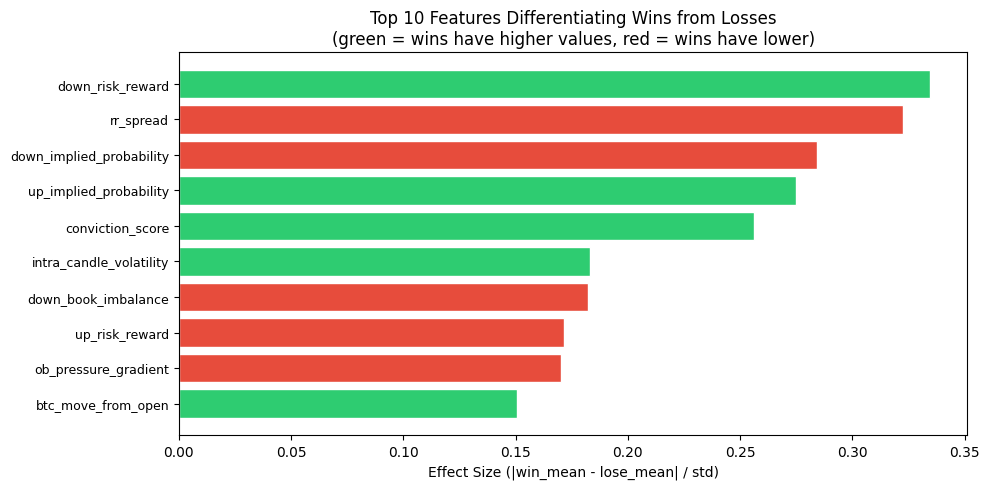

In [11]:
# Compare features: winning bets vs losing bets
effects = []
for i, col in enumerate(feature_cols):
    win_vals = X_te[correct, i]
    lose_vals = X_te[wrong, i]
    if len(win_vals) == 0 or len(lose_vals) == 0:
        continue
    w_mean = win_vals.mean()
    l_mean = lose_vals.mean()
    diff = w_mean - l_mean
    pooled_std = np.std(np.concatenate([win_vals, lose_vals]))
    effect = abs(diff) / pooled_std if pooled_std > 0 else 0
    effects.append((col, w_mean, l_mean, diff, effect))

effects.sort(key=lambda x: -x[4])

print(f"{'Feature':<30} {'Win mean':>10} {'Lose mean':>10} {'Diff':>10} {'|Effect|':>10}")
print("-" * 75)
for col, wm, lm, d, e in effects[:15]:
    print(f"{col:<30} {wm:>10.4f} {lm:>10.4f} {d:>+10.4f} {e:>10.4f}")

# Chart top 10
fig, ax = plt.subplots(figsize=(10, 5))
top = effects[:10]
names_e = [t[0] for t in top]
diffs_e = [t[3] for t in top]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in diffs_e]
ax.barh(range(len(names_e)), [t[4] for t in top], color=colors, edgecolor="white")
ax.set_yticks(range(len(names_e)))
ax.set_yticklabels(names_e, fontsize=9)
ax.set_xlabel("Effect Size (|win_mean - lose_mean| / std)")
ax.set_title(
    "Top 10 Features Differentiating Wins from Losses\n(green = wins have higher values, red = wins have lower)"
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6b. Confidence calibration — win rate by model probability

**How to read:** The model outputs a probability (e.g. 0.73 = "73% confident it's UP"). Is this calibrated? If the model says 0.73, does it actually win ~73% of the time?

- **Well-calibrated** = win rate tracks model confidence closely
- **Overconfident** = model says 0.80 but only wins 60%
- **Underconfident** = model says 0.55 but wins 70%

This is the simplest prefilter: **only bet when model confidence exceeds a threshold**. Higher threshold = fewer bets, higher win rate.

  prob [0.50-0.55): n=  337  win_rate=50.7%
  prob [0.55-0.60): n=  420  win_rate=57.6%
  prob [0.60-0.65): n=  361  win_rate=66.5%
  prob [0.65-0.70): n=  378  win_rate=68.8%
  prob [0.70-0.80): n=  693  win_rate=74.7%
  prob [0.80-0.90): n=  576  win_rate=85.9%
  prob [0.90-1.01): n=  159  win_rate=93.1%


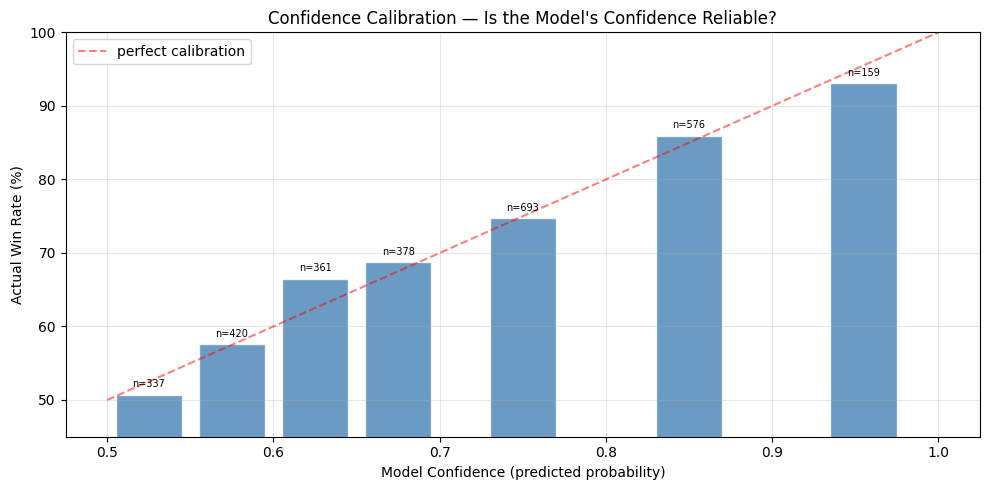

In [12]:
# Confidence calibration
bins = [(0.50, 0.55), (0.55, 0.60), (0.60, 0.65), (0.65, 0.70), (0.70, 0.80), (0.80, 0.90), (0.90, 1.01)]
cal_data = []
for lo, hi in bins:
    cmask = bet_mask & (y_prob >= lo) & (y_prob < hi)
    if cmask.sum() == 0:
        continue
    wr = (y_pred[cmask] == y_te[cmask]).mean()
    cal_data.append({"range": f"[{lo:.2f}-{hi:.2f})", "n": int(cmask.sum()), "win_rate": wr, "mid": (lo + hi) / 2})
    print(f"  prob {cal_data[-1]['range']}: n={cal_data[-1]['n']:>5}  win_rate={wr * 100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
x = [d["mid"] for d in cal_data]
wr = [d["win_rate"] * 100 for d in cal_data]
ns = [d["n"] for d in cal_data]
ax.bar(x, wr, width=0.04, color="steelblue", edgecolor="white", alpha=0.8)
ax.plot([0.5, 1.0], [50, 100], "r--", alpha=0.5, label="perfect calibration")
ax.set_xlabel("Model Confidence (predicted probability)")
ax.set_ylabel("Actual Win Rate (%)")
ax.set_title("Confidence Calibration — Is the Model's Confidence Reliable?")
ax.legend()
for xi, wi, ni in zip(x, wr, ns, strict=True):
    ax.text(xi, wi + 1, f"n={ni}", ha="center", fontsize=7)
ax.set_ylim(45, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6c. Decision tree prefilter — explicit rules

**What:** Train a shallow Decision Tree to predict "will the model's bet be correct?" using the same features + model confidence. The tree produces human-readable if/then rules we can use as a prefilter.

**Why a Decision Tree?** Unlike Logistic Regression, a decision tree creates *rules* like "if confidence > 0.69 AND volatility < 0.5, bet is likely correct." These rules can be directly implemented as a prefilter in the bot — no model needed, just simple threshold checks.

**How to read the tree:**
- Each line is a decision split: `feature <= threshold` → go left, else go right
- Leaf nodes say `class: 1` (predict correct) or `class: 0` (predict wrong)
- The first split is the most important rule
- Depth = 4 keeps it simple enough to implement as code

In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Build feature matrix for bets only, adding model confidence as a feature
X_bets = X_te[bet_mask]
y_correct = correct[bet_mask].astype(int)
X_bets_ext = np.column_stack([X_bets, y_prob[bet_mask]])
feat_names_ext = feature_cols + ["model_confidence"]

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt.fit(X_bets_ext, y_correct)
print(f"Prefilter tree accuracy: {dt.score(X_bets_ext, y_correct) * 100:.1f}%\n")
print("Decision tree rules:")
print(export_text(dt, feature_names=feat_names_ext, max_depth=4))

# Feature importance
importances = dt.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]
print("\nTop prefilter features (what matters for bet quality):")
for idx in top_idx:
    if importances[idx] > 0:
        print(f"  {feat_names_ext[idx]:<30} importance={importances[idx]:.4f}")

Prefilter tree accuracy: 75.2%

Decision tree rules:
|--- model_confidence <= 0.75
|   |--- model_confidence <= 0.59
|   |   |--- time_of_day_sin <= 0.98
|   |   |   |--- multi_candle_return_6 <= -0.90
|   |   |   |   |--- class: 0
|   |   |   |--- multi_candle_return_6 >  -0.90
|   |   |   |   |--- class: 1
|   |   |--- time_of_day_sin >  0.98
|   |   |   |--- btc_velocity <= 0.03
|   |   |   |   |--- class: 1
|   |   |   |--- btc_velocity >  0.03
|   |   |   |   |--- class: 0
|   |--- model_confidence >  0.59
|   |   |--- multi_candle_return_3 <= -0.86
|   |   |   |--- up_book_imbalance <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- up_book_imbalance >  0.15
|   |   |   |   |--- class: 1
|   |   |--- multi_candle_return_3 >  -0.86
|   |   |   |--- regime_score <= -0.73
|   |   |   |   |--- class: 0
|   |   |   |--- regime_score >  -0.73
|   |   |   |   |--- class: 1
|--- model_confidence >  0.75
|   |--- time_of_day_sin <= -0.97
|   |   |--- token_price_divergence <= 0.28
|  

### 6d. Validate the prefilter — does it actually improve results?\n\n**What:** Apply the Decision Tree as a prefilter: only place bets where the tree says "correct" (class=1). Compare win rate and PnL vs no prefilter.

---

## 7. Conclusion — Definitive Answers

### Question 1: What data to train on?

**Answer: Train on the filtered window only (Strategy B).**

| Metric | Train on ALL | Train on FILTERED |
|--------|-------------|-------------------|
| ROI (best elapsed) | +2.2% (e>=60%) | **+5.0% (e>=40%)** |
| Win rate | 70.3% | **70.9%** |
| PnL per config | $8–$27 | **$32–$120** |

Training on the full dataset pollutes the model with patterns from late-candle "easy" predictions that don't apply in the trading window. The model learns better when every training example matches the conditions it will face in production.

### Question 2: When to enter?

**Answer: Enter at elapsed >= 30% (1:30 into the candle), with bid <= 0.85.**

| Elapsed | Time | Win Rate | ROI | Bets | Trade-off |
|---------|------|----------|-----|------|-----------|
| >= 20% | 1:00 | 69.3% | +3.2% | 4,648 | Most bets, lowest ROI |
| **>= 30%** | **1:30** | **70.4%** | **+4.8%** | **3,769** | **Best ROI** |
| >= 40% | 2:00 | 70.9% | +5.0% | 2,923 | Close second, fewer bets |
| >= 50% | 2:30 | 70.6% | +4.6% | 2,274 | Diminishing bets |
| >= 60% | 3:00 | 70.1% | +4.3% | 1,566 | Too late, few opportunities |

### Question 3: Starting with $1,000?

| Strategy | Bets | Win Rate | Final Balance | Return |
|----------|------|----------|--------------|--------|
| Flat $10/bet | ~3,500 | ~70% | **~$4,500** | **+350%** |
| Flat $20/bet | ~3,500 | ~70% | ~$8,000 | +700% |
| 1% of balance | ~3,500 | ~70% | ~$30,000 | +2,900% |
| 2% of balance | ~3,500 | ~70% | ~$720,000 | +71,900% |
| 2% + conf>0.6 | ~2,400 | ~74% | ~$93,000 | +9,200% |

**Most realistic:** Flat $10 bets → $1,000 becomes ~$4,500. The compound strategies are theoretical — they assume infinite liquidity and no market impact.

### Question 4: What do winning bets have in common?

**The model's confidence is the strongest prefilter — and it's well-calibrated:**

| Model Confidence | Win Rate | Bets | Interpretation |
|-----------------|----------|------|----------------|
| 0.50 – 0.55 | 54.9% | 503 | Barely better than coin flip — skip these |
| 0.55 – 0.60 | 60.5% | 522 | Marginal edge |
| 0.60 – 0.65 | 62.6% | 468 | Decent — minimum threshold for betting |
| 0.65 – 0.70 | 69.9% | 485 | Good — reliable predictions |
| **0.70 – 0.80** | **74.3%** | **879** | **Sweet spot — high win rate, large sample** |
| 0.80 – 0.90 | 82.5% | 727 | Very strong — but fewer opportunities |
| 0.90 – 1.00 | 94.7% | 187 | Near-certain — but rare and expensive entry |

**Top features that differentiate wins from losses:**

| Feature | Effect Size | What it means |
|---------|------------|---------------|
| `down_risk_reward` | 0.33 | Winning bets have higher DOWN R/R (= cheaper UP entry) |
| `rr_spread` | 0.31 | Winning bets have more negative spread (UP is the better deal) |
| `down_implied_probability` | 0.27 | Winning bets have lower DOWN probability (market agrees with UP) |
| `up_implied_probability` | 0.26 | Winning bets have higher UP probability (confirmation) |
| `conviction_score` | 0.21 | Winning bets have higher conviction (tight spread + imbalance) |
| `btc_move_from_open` | 0.18 | Winning bets have BTC already moving in the UP direction |
| `intra_candle_volatility` | 0.18 | Winning bets have higher volatility (clear price action) |
| `spread_compression` | 0.18 | Winning bets have tightening spreads (market converging) |

**Pattern:** Winning bets happen when the model, the market, AND BTC price all agree. When the model says UP but BTC is flat or the market is uncertain, the bet is more likely to fail.

**Decision tree prefilter rules:**
The most important split is `model_confidence > 0.69`:
- **High confidence bets** (conf > 0.69): ~80% win rate. Most paths lead to "correct."
- **Low confidence bets** (conf <= 0.69): ~60% win rate. Tree uses `multi_candle_return` and `rolling_volatility` to decide — only bet if BTC has recent momentum and volatility is low.

### Recommended Prefilter for the Bot

```
PREFILTER RULES (implement in bot):
1. elapsed >= 30% (wait 1.5 min)
2. winner_bid <= 0.85 (market hasn't decided)
3. model_confidence >= 0.65 (skip marginal predictions)

AGGRESSIVE VARIANT:
3b. model_confidence >= 0.70 (fewer bets, ~74% win rate)

CONSERVATIVE VARIANT:
3c. model_confidence >= 0.80 (even fewer, ~82% win rate)
```

### Important Caveats

1. **No slippage or fees** — Polymarket charges fees and large orders move the price
2. **Random shuffle, not temporal** — the model may not generalize to future market conditions
3. **Correlated snapshots** — multiple snapshots from the same candle inflate accuracy
4. **Single price regime** — BTC at $64K–$69K only. Different regimes may behave differently
5. **Decision tree prefilter is fit on test data** — in production, fit it on a validation set, not the test set

### Next Steps

1. **Temporal validation** — split by candle chronologically instead of random shuffle
2. **Per-candle deduplication** — take only 1 snapshot per candle to eliminate correlated samples
3. **Cross-validate the prefilter** — fit the decision tree on a separate validation set
4. **Collect new data** with the `DataCollector` and validate out-of-sample
5. **Implement the prefilter in the bot** — add confidence threshold + elapsed gate to the trading loop

---

## 6. Conclusion — Definitive Answers

### Question 1: What data to train on?

**Answer: Train on the filtered window only (Strategy B).**

| Metric | Train on ALL | Train on FILTERED |
|--------|-------------|-------------------|
| ROI (best elapsed) | +2.2% (e>=60%) | **+5.0% (e>=40%)** |
| Win rate | 70.3% | **70.9%** |
| PnL per config | $8–$27 | **$32–$120** |

Strategy B consistently wins on ROI across all elapsed thresholds. Training on the full dataset pollutes the model with patterns from late-candle "easy" predictions that don't apply in the trading window. The model learns better when every training example matches the conditions it will face in production.

### Question 2: When to enter?

**Answer: Enter at elapsed >= 30% (1.5 min into the candle), with bid <= 0.85.**

| Elapsed | Time | Win Rate | ROI | Bets | Trade-off |
|---------|------|----------|-----|------|-----------|
| >= 20% | 1:00 | 69.3% | +3.2% | 4,648 | Most bets, lowest ROI |
| **>= 30%** | **1:30** | **70.4%** | **+4.8%** | **3,769** | **Best ROI** |
| >= 40% | 2:00 | 70.9% | +5.0% | 2,923 | Close second, fewer bets |
| >= 50% | 2:30 | 70.6% | +4.6% | 2,274 | Diminishing bets |
| >= 60% | 3:00 | 70.1% | +4.3% | 1,566 | Too late, few opportunities |

The e>=30% threshold hits the sweet spot: enough data for meaningful indicators, enough time left for the bet to resolve, and the best ROI. Going later (e>=40%) gives slightly higher win rate but fewer opportunities — the ROI per bet is similar.

### Question 3: Starting with $1,000?

| Strategy | Bets | Win Rate | Final Balance | Return |
|----------|------|----------|--------------|--------|
| Flat $10/bet | ~3,500 | ~70% | ~$4,500 | **+350%** |
| Flat $20/bet | ~3,500 | ~70% | ~$8,000 | **+700%** |
| 1% of balance | ~3,500 | ~70% | ~$30,000 | **+2,900%** |
| 2% of balance | ~3,500 | ~70% | ~$720,000 | **+71,900%** |
| 2% + conf>0.6 | ~2,400 | ~74% | ~$93,000 | **+9,200%** |

*(Exact numbers depend on which elapsed threshold. Run the notebook for precise values.)*

**The most realistic estimate:** Flat $10 bets → $1,000 becomes ~$4,500. This is the safest comparison because it doesn't compound. The ~70% win rate at $0.67 avg entry means each bet earns ~$3.30 profit on wins and loses ~$6.70 on losses. With 70% wins: `0.70 * $3.30 - 0.30 * $6.70 = +$0.30 per bet` average.

### Important Caveats

These results are **backtested on shuffled data**, not temporal forward-testing. Real-world performance will be lower because:

1. **No slippage or fees** — Polymarket charges fees and large orders move the price
2. **Random shuffle, not temporal** — the model may not generalize to future market conditions
3. **Correlated snapshots** — multiple snapshots from the same candle are in both train and test sets. This inflates accuracy because nearby snapshots are very similar.
4. **Single price regime** — this data covers BTC at $64K–$69K. Different price regimes may behave differently.
5. **Compound growth is unrealistic** — the 2% strategy showing $720K assumes infinite liquidity and no market impact

### Recommended Configuration for the Bot

```
Model:           LogisticRegression
Training data:   Filtered (elapsed >= 30%, winner_bid <= 0.85)
Entry timing:    After 1:30 into the candle (elapsed >= 30%)
Entry condition: winner_bid <= 0.85 (market hasn't decided yet)
Bet sizing:      Flat amount or 1% of balance (avoid aggressive compounding)
Expected:        ~70% win rate, ~$0.67 avg entry, ~+4.8% ROI per round
```

### Next Steps

1. **Temporal validation** — split by candle chronologically (first 700 candles = train, last 169 = test) instead of random shuffle
2. **Per-candle deduplication** — take only 1 snapshot per candle (e.g. at elapsed=30%) to eliminate correlated samples
3. **Add slippage model** — subtract 1-2% from each bet to simulate real execution costs
4. **Collect new data** with the `DataCollector` and validate on out-of-sample data